In [1]:
# %matplotlib widget
import sys
sys.path.append('..')

import os
import sys
import numpy as np
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
from mpl_toolkits import mplot3d
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
import math
from IPython.display import HTML
from tqdm import tqdm
import random
from numpy.lib import recfunctions as rfn

from sklearn.cluster import DBSCAN
from scipy.interpolate import interp1d
from scipy.spatial import KDTree
from scipy.interpolate import interpn
# import cupy as cp
import time
import numba as nb

# 画图部分
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial
import matplotlib.cm as cm

# ROC曲线部分
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

# 插值
import torch
# import torch.cuda as cuda
from scipy.interpolate import griddata

# 系数拟合部分
from scipy.optimize import curve_fit
from sklearn import svm

In [2]:
# 概率比较部分
from scipy.special import gammaln
# import torch.distributions as dist

# 位置重建函数
import position_rec as pos

import DE
from DE import DESimulation

import os
import glob
import re

Trans into torch tensor input


In [4]:
# data = np.load("../sim_config/cevns_sim.npz")
data_original = np.load("./data/e_spectrum_relics.npz")

In [30]:
# 创建一个字典来复制数据
new_data_dict = {key: data_original[key] for key in data_original.files}

# 修改特定的数据, 每个pe模拟1e5个数据
new_data_dict['CEvNS'] = (np.ones(len(new_data_dict['CEvNS'])) * 1e4).astype(int)

new_data_dict['CEvNS'][:3] = 1

print(new_data_dict['CEvNS'])

np.savez('./sim_config/acceptance_sim_1e4.npz',**new_data_dict)

[    1     1     1 10000 10000 10000 10000 10000 10000 10000 10000 10000
 10000 10000 10000 10000 10000 10000 10000 10000]


In [31]:
index = 2

In [32]:
def rndm(a, b, g, size=1):
    """Power-law gen for pdf(x)\propto x^{g-1} for a<=x<=b"""
    r = np.random.random(size=size)
    ag, bg = a**g, b**g
    return (ag + (bg - ag) * r) ** (1.0 / g)


def dense_muon_gen(modified_merged_muon_array, interp_num, event_time, dead_time_ratio):
    """生成dense_muon_points数据, 为保证速度，从muon track的首尾线性插值，并且能量均匀分布"""

    # 定义每个元素的类型
    element_types = [
        ("eventId", "<i4"),
        ("energy", "<f8"),
        ("xd", "<f8"),
        ("yd", "<f8"),
        ("zd", "<f8"),
        ("muon_time", "<f8"),
        ("num_e", "<u4"),
        ("num_e_delayed", "<u4"),
    ]
    # 定义muon模拟数量
    muon_sim_num = modified_merged_muon_array["eventId"][-1] + 1
    dense_muon_points = np.zeros(int(muon_sim_num * interp_num), dtype=element_types)
    # 获取modified_merged_muon_array中每个eventId刷新坐标
    unique_elements, start_indices = np.unique(
        modified_merged_muon_array["eventId"], return_index=True
    )
    end_indices = np.concatenate(
        [
            start_indices[1:] - 1,
            np.array(
                [
                    len(modified_merged_muon_array) - 1,
                ]
            ),
        ]
    )

    start_point, end_point = (
        modified_merged_muon_array[start_indices],
        modified_merged_muon_array[end_indices],
    )
    gap_x = -start_point["xd"] + end_point["xd"]
    gap_y = -start_point["yd"] + end_point["yd"]
    gap_z = -start_point["zd"] + end_point["zd"]

    # 创建长度为100的0-1之间差值数组
    arr = np.tile(np.arange(0, 100 / 99, 1 / 99), (muon_sim_num, 1))
    x_dense, y_dense, z_dense = (
        arr * gap_x[:, np.newaxis],
        arr * gap_y[:, np.newaxis],
        arr * gap_z[:, np.newaxis],
    )
    x_dense, y_dense, z_dense = (
        x_dense + start_point["xd"][:, np.newaxis],
        y_dense + start_point["yd"][:, np.newaxis],
        z_dense + start_point["zd"][:, np.newaxis],
    )

    dense_muon_points["xd"], dense_muon_points["yd"], dense_muon_points["zd"] = (
        x_dense.flatten(),
        y_dense.flatten(),
        z_dense.flatten(),
    )
    dense_muon_points["eventId"] = (np.arange(muon_sim_num * interp_num) / 100).astype(
        "uint32"
    )

    # 计算每个muon沉积能量总和及电子总和

    # 提取 eventId 和 electron_num 列
    event_ids = modified_merged_muon_array["eventId"]
    electron_nums = modified_merged_muon_array["electronNum"]
    muon_step_energy = modified_merged_muon_array["energy"]

    # 使用 numpy.unique 获取唯一 eventId 和对应的索引
    unique_event_ids, event_id_indices = np.unique(event_ids, return_inverse=True)

    # 使用 numpy.bincount 计算每个相同 eventId 的 electron_num 总和
    muon_electron_sum = np.bincount(event_id_indices, weights=electron_nums)
    muon_electron_energy = np.bincount(event_id_indices, weights=muon_step_energy)
    muon_electron_sum.astype("uint32")

    # 补全dense_muon_points中的energy，num_e以及num_e_delayed
    average_electron = (muon_electron_sum / 100).astype("uint32")
    average_energy = (muon_electron_energy / 100).astype("uint32")

    dense_muon_points["energy"] = average_energy[dense_muon_points["eventId"]]
    dense_muon_points["num_e"] = average_electron[dense_muon_points["eventId"]]
    dense_muon_points["muon_time"] = event_time[dense_muon_points["eventId"]]

    # 定义残留比例
    delay_ratio = ((dense_muon_points["zd"] - 100) / (-1.7) / 1000 + 0.02) / 100
    delay_ratio[delay_ratio < 0.001] = 0.001
    dense_muon_points["num_e_delayed"] = (
        dense_muon_points["num_e"] * delay_ratio * dead_time_ratio
    )

    return dense_muon_points


In [33]:
file_load_once = 100
cevns_sim = DESimulation("./sim_config/CEvNS_acceptance.yaml")

In [34]:
muon_file_list = []
for i in range(file_load_once):
    # print(i)
    file_index = index * file_load_once + i
    filename = cevns_sim.muon_track_file + \
        "muon_track." + str(file_index) + ('.npy')
    # print(filename)
    muon_file_list.append(filename)

cevns_sim.generate_muon_points(muon_file_list)
# cevns_sim.generate_CEVNS_points()
# cevns_sim.generate_CEVNS_pattern()
# cevns_sim.CEVNS_position_recon()
# cevns_sim.generate_CEVNS_recon_pattern()
# cevns_sim.CEVNS_sp_cor()


  2%|██▋                                                                                                                                  | 2/100 [00:00<00:05, 17.02it/s]

First muon track file: ./muon_track/muon_track.200.npy


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 21.42it/s]


Last muon track file: ./muon_track/muon_track.299.npy
Number of muon events: 314738
merged_muon_array data type: [('eventId', '<i4'), ('type', 'i1'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('td', '<f8')]
dense_muon_points data type:  [('eventId', '<i4'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('muon_time', '<f8'), ('num_e', '<u4'), ('num_e_delayed', '<u4')]


In [13]:
cevns_points = np.concatenate(cevns_sim.cevns_points[2:])

In [14]:
def calculate_poisson_probabilities_log(data_array, mean_array):
    # 计算每个元素的对数概率
    log_probabilities = (
        -mean_array + data_array * np.log(mean_array) - gammaln(data_array + 1)
    )
    return log_probabilities

# 定义cevns点的三参数
cevns_info = np.zeros(
    len(cevns_points),
    dtype=np.dtype(
        [
            ("area", "<f8"),
            ("st_cor", "<f8"),
            ("pattern", "<f8"),
            ("e_num", "uint32"),
        ]
    ),
)

cevns_info["area"] = np.sum(cevns_points["pe_by_area"], axis=1)
cevns_info["st_cor"] = np.log(cevns_points["st_cor"])
# cevns_info['st_cor_new'] = np.log(cevns_points['st_cor_new'])
cevns_info["pattern"] = np.sum(
    calculate_poisson_probabilities_log(
        cevns_points["pe_by_area"][:, :64], cevns_points["recons_light_pattern"][:, :64]
    ),
    axis=1,
)

cevns_info["e_num"] = cevns_points["num_e"]

In [15]:
k_st_coefficients = np.load("cut_config/k_st_coefficients.npz")['arr_0']
b_coefficients = np.load("cut_config/b_coefficients.npz")['arr_0']

sigma_se = 190e-9

In [16]:
def cevns_waveform_gen(pe_info, sigma_se, z):

    pe_num = len(pe_info)

    Dl = 12
    vd = 0.174 * 1000000

    # cevns_z = np.random.uniform(0,24)
    cevns_z = z
    t = cevns_z / vd
    # sigma_d = math.sqrt((2 * Dl * t) / (vd ** 2) + sigma_0 ** 2)
    sigma_t = np.sqrt((2 * Dl * t) / (vd**2))
    sigma = sigma_t
    pe_e_time = np.zeros(len(pe_info))

    for e_id in np.unique(pe_info["e_id"]):
        e_time = np.random.normal(0, sigma)
        mask = pe_info["e_id"] == e_id
        pe_e_time[mask] = e_time
    # print("#########", pe_e_time)

    se_signal_delay = np.random.normal(0, sigma_se, pe_num)
    pe_time = pe_e_time + se_signal_delay
    pe_time = pe_time - np.mean(pe_time)
    # print(pe_time)
    sample_index = pe_time / (4e-9)
    sample_index = sample_index.astype(int)
    # print(sample_index)
    waveform = np.zeros(3500)
    np.add.at(waveform, sample_index + 1750, pe_info["area"] / 6e6)
    std = np.std(sample_index) * 4e-9
    # waveform[sample_index + 1750] += (pe_info['area']/6e6)
    # print(pe_info['area']/6e6)
    # fig = plt.figure(figsize=(7, 4))
    # plt.plot(waveform[1000:-1000])
    # plt.show()
    return waveform, std


In [26]:
# 定义cevns点的三参数
cevns_inf_pass_pattern_dtype = np.dtype([
                                        ("area", "<f8"),
                                        ("st_cor", "<f8"),
                                        ("pattern", "<f8"),
                                        ("e_num", "uint32"),
                                        ("waveform", ("<f8", (3500,)))
                                        ]
                                        )
                                        

remain_cevns_id_list = []
accumulate_num = 0
cevns_pass_pattern_info_list = []
for i in range(len(cevns_sim.cevns_points)):
    # for i in range(len(cevns_sim.cevns_e_spectrum)):

    cevns_points = cevns_sim.cevns_points[i]
    e_num = cevns_sim.cevns_e_num[i]
    # cevns_id = cevns_points['cevnsID'] - accumulate_num
    cevns_id = np.arange(0, len(cevns_points))
    # print(np.min(cevns_id))

    # st_mask
    st_mask = cevns_points["st_cor"] > 0

    cevns_info = np.zeros(
        len(cevns_points[st_mask]),
        dtype=np.dtype([("area", "<f8"), ("st_cor", "<f8"), ("pattern", "<f8"),("e_num", "uint32"),]),
    )
    cevns_info["area"] = np.sum(cevns_points[st_mask]["pe_by_area"], axis=1)
    cevns_info["st_cor"] = np.log(cevns_points[st_mask]["st_cor"])
    cevns_info["e_num"] = cevns_points[st_mask]["num_e"]
    cevns_info["pattern"] = np.sum(
        calculate_poisson_probabilities_log(
            cevns_points[st_mask]["pe_by_area"][:, :64],
            cevns_points[st_mask]["recons_light_pattern"][:, :64],
        ),
        axis=1,
    )
    
    score_cevns = cevns_info['pattern'] - ((cevns_info['area'] * k_st_coefficients[0] + k_st_coefficients[1] ) * cevns_info['st_cor']) 
    b_cevns = cevns_info['area'] * b_coefficients[0] + b_coefficients[1] 

    cevns_pass_pattern = cevns_info[score_cevns > b_cevns]

    cevns_id_remain = cevns_id[score_cevns > b_cevns]

    cevns_pe = cevns_sim.cevns_pe_info[i]

    ########
    # print(cevns_pe['event_id'][-1])
    # print(np.max(cevns_id))
    # print(len(cevns_id_remain) / len(cevns_id))

    accumulate_num += len(cevns_points)

    waveform_list = []
    std_list = []
    z_list = np.linspace(0, 24, len(cevns_id_remain))
    print('e_num:{}, pattern cut acceptance:{}'.format(e_num, len(cevns_pass_pattern) / len(cevns_info)))
    for j in tqdm(range(len(cevns_id_remain))):

        cevns_id_event = cevns_id_remain[j]
        # print('cevns_id_event: ', cevns_id_event)

        pe_mask = cevns_pe["event_id"] == cevns_id_event
        pe_info = cevns_pe[pe_mask]
        # print(len(pe_info))
        pe_num = len(pe_info)
        pe_area = np.sum(pe_info["area"])
        #         print("area1: ", pe_area / 6e6)

        #         print("area2: ", cevns_pass_pattern[j]['area'])

        #         print("Score: ", score_cevns[score_cevns > 0][j])

        waveform, std = cevns_waveform_gen(pe_info, sigma_se, z_list[j])
        # waveform_top,std_top = top_waveform_gen(pe_info,sigma_se)
        waveform[waveform < 0] = 0
        waveform_list.append(waveform)
        std_list.append(std)
    waveform_enum = np.array(waveform_list)
    
    if len(cevns_pass_pattern) >=1:
        cevns_pass_pattern_info = np.zeros(len(cevns_pass_pattern),dtype = cevns_inf_pass_pattern_dtype)
        cevns_pass_pattern_info['area'] = cevns_pass_pattern['area']
        cevns_pass_pattern_info['st_cor'] = cevns_pass_pattern['st_cor']
        cevns_pass_pattern_info['pattern'] = cevns_pass_pattern['pattern']
        cevns_pass_pattern_info['e_num'] = cevns_pass_pattern['e_num']
        cevns_pass_pattern_info['waveform'] = waveform_enum
        cevns_pass_pattern_info_list.append(cevns_pass_pattern_info)

        
cevns_pass_pattern_info_array = np.concatenate(cevns_pass_pattern_info_list)
np.save('acceptance_analysis_waveform/wf_pass_pattern_cevns_{}.npy'.format(index), cevns_pass_pattern_info_array)

e_num:1, pattern cut acceptance:0.0


0it [00:00, ?it/s]


e_num:2, pattern cut acceptance:0.0


0it [00:00, ?it/s]


e_num:3, pattern cut acceptance:0.113


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 886/886 [00:00<00:00, 1433.01it/s]


e_num:9, pattern cut acceptance:0.935


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 935/935 [00:00<00:00, 1758.59it/s]


e_num:10, pattern cut acceptance:0.957


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 957/957 [00:00<00:00, 1617.93it/s]


分析模拟得到的剩余Pattern的波形
=======

In [3]:
import torch
import torch.nn as nn
import pickle
from PIL import Image
import h5py

#神经网络的结构，得跑一下才能把后面有些定义的变量弄进去，不耗时间
class WaveformClassifier(nn.Module):
    def __init__(self):
        super(WaveformClassifier, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.global_pool = nn.AdaptiveAvgPool1d(1)  # 使用全局平均池化层
        self.fc = nn.Sequential(
            nn.Linear(128, 64),  # 修改全连接层的输入维度
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 2)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.global_pool(x).squeeze(2)
        x = self.fc(x)
        return x
    

In [76]:
def list_files_with_prefix(directory, prefix):  
    try:  
        # 获取指定目录下的所有文件和目录  
        files_and_dirs = os.listdir(directory)  
          
        # 筛选出以指定开头前缀的文件  
        matching_files = [os.path.join(directory, f) for f in files_and_dirs if f.startswith(prefix) and os.path.isfile(os.path.join(directory, f))]  
          
        return matching_files  
    except FileNotFoundError:  
        print(f"The directory '{directory}' does not exist.")  
        return []  
    except Exception as e:  
        print(f"An error occurred: {e}")  
        return []  
  
directory_path = "acceptance_analysis_waveform"  
cevns_pass_file_prefix = "wf_pass_pattern_cevns_"  
cevns_fail_file_prefix = "wf_fail_pattern_cevns_"  
cevns_pass_files = list_files_with_prefix(directory_path, cevns_pass_file_prefix)  
cevns_fail_files = list_files_with_prefix(directory_path, cevns_fail_file_prefix)

In [77]:
sigma_array = ((np.arange(3500) - np.mean(np.arange(3500))) * 4)**2
time_array = (np.arange(3500) - np.mean(np.arange(3500))) * 4

def width_calculate(waveform,sigma_array):
    waveform_std = np.sum(waveform * sigma_array / np.sum(waveform))**0.5
    return waveform_std

对于未通过Pattern cut的所有真实事件，进行统计
======

In [78]:
# for i in tqdm(range(len(cevns_fail_files))):
cevns_fail_info_list = []
for i in tqdm(range(len(cevns_fail_files))):
    cevns_fail_file = cevns_fail_files[i]
    cevns_fail_info = np.load(cevns_fail_file)
    cevns_fail_info_list.append(cevns_fail_info)
    
cevns_fail_info = np.concatenate(cevns_fail_info_list)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 702.01it/s]


In [79]:
# 定义每个维度的bins  
bins_area = np.linspace(90,300,22)  
bins_e_num = np.linspace(2.5,10.5,9) 
bins_z = np.linspace(0,24,25)
  
# 将bins放在一个列表中  
bins = [bins_area, bins_e_num, bins_z]  
  
# 从结构化数组中提取数据  
pattern_fail_array = np.stack((cevns_fail_info['area'], cevns_fail_info['e_num'], cevns_fail_info['z']), axis=-1)
  
# 计算多维直方图  
pattern_fail_hist, bin_edges = np.histogramdd(pattern_fail_array, bins=bins)  

对于通过Pattern cut的所有真实事件，统计waveform得分与宽度，分别对保留与去除事件进行统计
======

In [80]:
cevns_waveform_info_dtype = np.dtype([('waveform_score', '<f8'), ('width', '<f8'),])

In [81]:
cevns_pass_info_list = []
cevns_pass_waveform_info_list = []
cevns_waveform_info_list = []
for i in tqdm(range(len(cevns_pass_files))):
# for i in tqdm(range(10)):
    cevns_file = cevns_pass_files[i]
    cevns_info = np.load(cevns_file)
    
    # 重新选取对应的字段，不存储array
    cevns_pass_info = np.zeros(len(cevns_info),dtype = cevns_fail_info.dtype)
    cevns_pass_info['area'] = cevns_info['area']
    cevns_pass_info['st_cor'] = cevns_info['st_cor']
    cevns_pass_info['pattern'] = cevns_info['pattern']
    cevns_pass_info['e_num'] = cevns_info['e_num']
    cevns_pass_info['z'] = cevns_info['z']
    cevns_pass_info_list.append(cevns_pass_info)
    
    # 读取波形并分析对应的waveform score和宽度
    waveform_array = np.copy(cevns_info['waveform'])
    
    test_de_data = waveform_array.reshape(-1, 1, 3500)
    test_de_labels = np.zeros(len(test_de_data))
    test_de_pe = np.sum(np.sum(test_de_data,axis = 1),axis = 1)

    test_data = test_de_data.reshape(-1, 1, 3500)
    test_labels = np.zeros(len(test_data))
    test_pe = np.sum(np.sum(test_data,axis = 1),axis = 1)
    
    
    # 将测试集数据和标签转换为PyTorch张量
    test_data = torch.from_numpy(test_data).float()
    test_labels = torch.from_numpy(test_labels).long()

    # 创建测试集数据集和数据加载器
    test_dataset = torch.utils.data.TensorDataset(test_data, test_labels)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 加载模型
    model = WaveformClassifier()
    model.load_state_dict(torch.load('sim_config/waveform_classifier.pth'))


    # 测试模式
    model.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0
    test_confusion_matrix = torch.zeros(2, 2)
    criterion = nn.CrossEntropyLoss()

    num_epochs = 2
    with torch.no_grad():
        for batch_data, batch_labels in test_dataloader:
            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)
            test_loss += loss.item() * batch_data.size(0)

            # 计算测试集准确率和混淆矩阵
            _, predicted = torch.max(outputs, 1)
            test_total += batch_labels.size(0)
            test_correct += (predicted == batch_labels).sum().item()

            for i in range(len(predicted)):
                test_confusion_matrix[batch_labels[i]][predicted[i]] += 1

    # 计算平均测试集损失函数和准确率
    test_loss /= len(test_dataset)
    test_accuracy = test_correct / test_total

    # 计算标签0判断为标签1和标签1判断为标签0的概率
    test_false_positive = test_confusion_matrix[0][1] / test_confusion_matrix[0].sum()
    test_false_negative = test_confusion_matrix[1][0] / test_confusion_matrix[1].sum()

    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
    print(f"Test False Positive Rate: {test_false_positive:.4f}, Test False Negative Rate: {test_false_negative:.4f}")


    # 在测试集上进行评估
    model.eval()
    test_confusion_matrix = torch.zeros(2, 2)

    # 在测试集上计算预测分数
    with torch.no_grad():
        model.eval()
        outputs = model(test_data)
        scores = torch.softmax(outputs, dim=1)

    # 绘制预测分数的分布
    scores_label_0 = scores[test_labels == 0]
    scores_label_1 = scores[test_labels == 1]
    
    DE_waveform_score = scores_label_0[:, 0].numpy()
    
    # 计算宽度
    width_list = []
    for j in range(len(waveform_array)):
        waveform = waveform_array[j]
        width_list.append(width_calculate(waveform,sigma_array))
    width_array = np.array(width_list)
    
    cevns_waveform_info = np.zeros(len(cevns_info),dtype = cevns_waveform_info_dtype)
    cevns_waveform_info['waveform_score'] = DE_waveform_score
    cevns_waveform_info['width'] = width_array
    cevns_waveform_info_list.append(cevns_waveform_info)

    del waveform_array
    del cevns_info

  0%|                                                                                                                                              | 0/50 [00:00<?, ?it/s]

Test Loss: 0.0185, Test Accuracy: 0.9974
Test False Positive Rate: 0.0026, Test False Negative Rate: nan


  2%|██▋                                                                                                                                   | 1/50 [00:38<31:19, 38.35s/it]

Test Loss: 0.0187, Test Accuracy: 0.9972
Test False Positive Rate: 0.0028, Test False Negative Rate: nan


  4%|█████▎                                                                                                                                | 2/50 [01:17<30:58, 38.72s/it]

...

 96%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋     | 48/50 [32:04<01:17, 38.80s/it]

Test Loss: 0.0196, Test Accuracy: 0.9971
Test False Positive Rate: 0.0029, Test False Negative Rate: nan


 98%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎  | 49/50 [32:43<00:38, 38.87s/it]

Test Loss: 0.0185, Test Accuracy: 0.9978
Test False Positive Rate: 0.0022, Test False Negative Rate: nan


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [33:22<00:00, 40.05s/it]


In [86]:
cevns_pass_info = np.concatenate(cevns_pass_info_list)
cevns_pass_width_info = np.concatenate(cevns_waveform_info_list)

In [87]:
# 通过width和cut的事件
waveform_score_mask = cevns_pass_width_info['waveform_score'] > 0.8
waveform_width_mask = cevns_pass_width_info['width'] > 220

In [88]:
# 通过pattern与waveform的Cevns结果统计
cevns_pass_pattern_waveform = cevns_pass_info[waveform_score_mask & waveform_width_mask]

# 从结构化数组中提取数据  
cevns_pass_pattern_waveform_array = np.stack((cevns_pass_pattern_waveform['area'], 
                                                cevns_pass_pattern_waveform['e_num'], 
                                                cevns_pass_pattern_waveform['z']), axis=-1)
  
# 计算多维直方图  
cevns_pass_pattern_waveform_hist, bin_edges = np.histogramdd(cevns_pass_pattern_waveform_array, bins=bins) 

In [89]:
# 通过pattern未通过waveform的结果统计
cevns_pass_pattern_fail_waveform = cevns_pass_info[~(waveform_score_mask & waveform_width_mask)]

# 从结构化数组中提取数据  
cevns_pass_pattern_fail_waveform_array = np.stack((cevns_pass_pattern_fail_waveform['area'], 
                                                cevns_pass_pattern_fail_waveform['e_num'], 
                                                cevns_pass_pattern_fail_waveform['z']), axis=-1)
  
# 计算多维直方图  
cevns_pass_pattern_fail_waveform_hist, bin_edges = np.histogramdd(cevns_pass_pattern_fail_waveform_array, bins=bins) 

合并所有的统计结果并绘图
======

In [114]:
bins_area = np.linspace(90,300,22)  
bins_e_num = np.linspace(2.5,10.5,9) 
bins_z = np.linspace(0,24,25)

cevns_spectrum_ratio = np.array([0.37417449009388115,
 0.3109397312767753,
 0.16717200606407276,
 0.07893294719536634,
 0.03659243910926931,
 0.017214206570478847,
 0.008146097753173038,
 0.0038070456845482148,
 0.0016640199682396188,
 0.0007810093721124653,
 0.0003360040320483846,
 0.00015200182402188826,
 6.600079200950411e-05,
 2.2000264003168037e-05])

In [132]:
len(bins_area)

22

In [131]:
cevns_hist = cevns_pass_pattern_waveform_hist + cevns_pass_pattern_fail_waveform_hist + pattern_fail_hist
cevns_pass_pattern_waveform_ratio = cevns_pass_pattern_waveform_hist / cevns_hist
ratio_valid_mask = cevns_hist > 50
cevns_pass_pattern_waveform_ratio[~ratio_valid_mask] = 0
np.save("cevns_pass_pattern_waveform_ratio", cevns_pass_pattern_waveform_ratio)
 
cevns_pass_pattern_waveform_ratio_e_z = np.sum(cevns_pass_pattern_waveform_hist, axis = 0) / np.sum(cevns_hist, axis = 0)

/tmp/ipykernel_602191/255457866.py:2: RuntimeWarning: invalid value encountered in divide
  cevns_pass_pattern_waveform_ratio = cevns_pass_pattern_waveform_hist / cevns_hist


In [130]:
cevns_pass_pattern_waveform_ratio[:,-1,:]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.   

In [115]:
cevns_pass_pattern_waveform_ratio_z = np.sum(np.sum(cevns_pass_pattern_waveform_hist[3:], axis = 0) * 
                                             cevns_spectrum_ratio[3:11][:,np.newaxis],axis = 0) / np.sum(np.sum(cevns_hist[3:], axis = 0) * 
                                                                                                         cevns_spectrum_ratio[3:11][:,np.newaxis],axis = 0)

cevns_pass_pattern_waveform_ratio_e = np.sum(np.sum(cevns_pass_pattern_waveform_hist[3:], axis = 0),axis = 1)/np.sum(np.sum(cevns_hist[3:], axis = 0),axis = 1)

In [126]:
cevns_pass_pattern_waveform_ratio.shape

(21, 8, 24)

In [120]:
cevns_pass_pattern_waveform_ratio_e.shape,bins_e_num.shape

((8,), (9,))

/tmp/ipykernel_602191/1177569741.py:19: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels([r'${}$'])


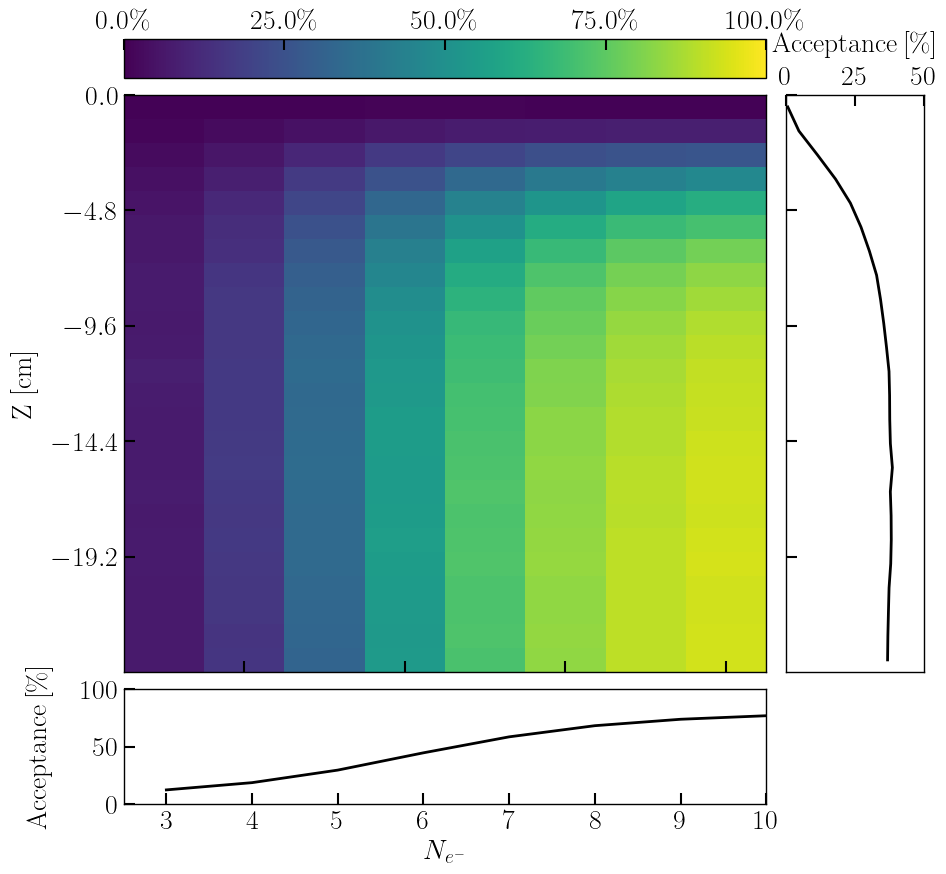

In [125]:
from matplotlib import colors

e_bins = np.arange(3,11,1)

norm = colors.Normalize(vmin=0, vmax=100)
fig = plt.figure(figsize=(10,9))
plt.style.use('./relics.mplstyle') 
gs = matplotlib.gridspec.GridSpec(3,2, height_ratios=[0.05,0.75,0.15], width_ratios=[0.7,0.15])
gs.update(left=0.15, right=0.95, bottom=0.08, top=0.93, wspace=0.05, hspace=0.07)

ax1 = plt.subplot(gs[1,0])
mesh = ax1.pcolormesh(bins_e_num,bins_z * 10, cevns_pass_pattern_waveform_ratio_e_z.T[::-1, :] * 100,norm = norm)

# 设置 x 和 y 轴
# ax1.set_yticks(np.arange(0, 240, 48))
ax1.set_ylabel(r'$\mathrm{Z\ [cm]}$', labelpad=10)
ax1.set_yticks(np.arange(48, 288, 48))
ax1.set_yticklabels([r'${}\mathrm{{}}$'.format(i) for i in np.arange(-192, 48, 48)/10])
ax1.set_xticklabels([r'${}$'])
ax1.set_xlim([2.5,10.5])

cbax = plt.subplot(gs[0,0])
# 为 colorbar 创建 colorbar
cbar = plt.colorbar(mappable=mesh, cax=cbax, orientation='horizontal', ticklocation='top')
cbar.set_ticks([0, 25, 50, 75, 100])
cbar.set_ticklabels([r'${}\%$'.format(i) for i in np.arange(0, 1.25, 0.25)*100])

ax1v = plt.subplot(gs[1,1])
ax1v.plot((cevns_pass_pattern_waveform_ratio_z * 100)[::-1],np.arange(0, 240, 10)+5,color='k',)
# ax1v.set_ylabel(r'$\mathrm{}$')
ax1v.set_xlabel(r'$\mathrm{Acceptance\left [ \% \right ] }$', labelpad=10)
ax1v.set_xticks(np.arange(0,75,25))
ax1v.set_xticklabels([r'${}\mathrm{{}}$'.format(i) for i in np.arange(0,75,25)])
ax1v.set_yticks(np.arange(48, 288, 48))
ax1v.set_yticklabels([])
ax1v.set_xlim([0,50])
ax1v.set_ylim([0,240])
ax1v.xaxis.tick_top()
ax1v.xaxis.set_label_position('top')

ax1h = plt.subplot(gs[2,0])
ax1h.plot(e_bins,cevns_pass_pattern_waveform_ratio_e * 100,color='k',)
ax1h.set_xlim([2.5,9.5])
ax1h.set_ylim([0,100])
ax1h.set_xticks(e_bins)
ax1h.set_xticklabels([])
ax1h.set_yticks(np.arange(0,150,50))
ax1h.set_yticklabels([r'${}\mathrm{{}}$'.format(i) for i in np.arange(0,150,50)])
ax1h.set_ylabel(r'$\mathrm{Acceptance\left [ \% \right ] }$', labelpad=20)
ax1h.set_xticklabels([r'${}$'.format(i) for i in e_bins])
ax1h.set_xlabel(r'$N_{e^{-}}$')



cbax.tick_params(direction='in')
ax1.tick_params(direction='in')
ax1v.tick_params(direction='in')
ax1h.tick_params(direction='in')
# plt.tight_layout()
plt.plot()
plt.savefig("figure/Acceptance.pdf")
plt.show()

